In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [60]:
data = pd.read_json("results/run_report_2.json")
data = data[814:]
# Set device_count to 0 for the first 300 rows
data.loc[data.index[:300], "device_count"] = 0
data

,time,device_count,prompt_length,program,max_seq_len,max_tokens
814,0.287181,0,81,NaN,81,8
815,4.877782,0,751,NaN,751,75
816,38.798028,0,3951,NaN,3951,395
817,0.267590,0,81,NaN,81,8
818,5.708374,0,751,NaN,751,75
...,...,...,...,...,...,...
1269,39.295712,1,3951,NaN,3951,395
1270,0.266211,1,81,NaN,81,8
1271,4.633861,1,751,NaN,751,75
1272,39.165456,1,3951,NaN,3951,395


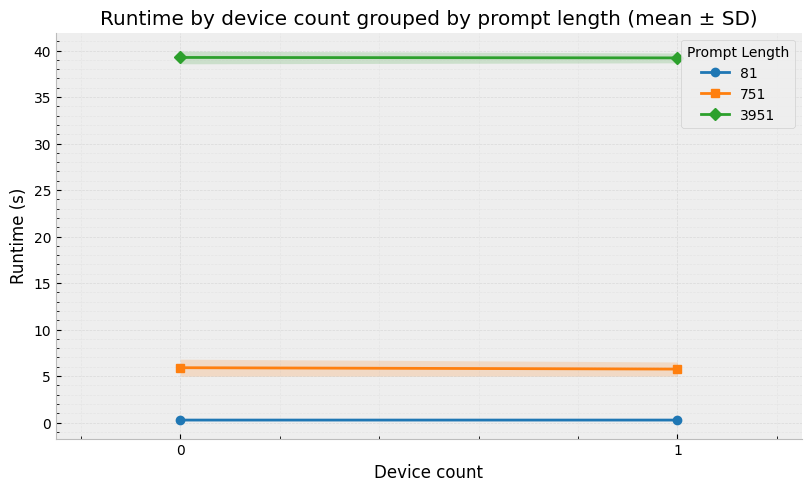

In [61]:
# Aggregate mean and standard deviation of runtime by prompt length and device count
stats = (
    data.groupby(["prompt_length", "device_count"], as_index=False)["time"]
        .agg(mean="mean", std="std")
)
stats["std"] = stats["std"].fillna(0.0)

# Polished plot: lines with markers + shaded ±SD bands, nicer style and legend
plt.style.use("bmh")
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

cmap = plt.get_cmap("tab10")
markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h", ">"]
xticks = sorted(stats["device_count"].unique())

for i, (prog, grp) in enumerate(stats.groupby("prompt_length", sort=False)):
    grp = grp.sort_values("device_count")
    color = cmap(i % 10)
    ax.plot(
        grp["device_count"], grp["mean"],
        color=color, marker=markers[i % len(markers)],
        linewidth=2, markersize=6, label=prog,
    )
    ax.fill_between(
        grp["device_count"],
        grp["mean"] - grp["std"],
        grp["mean"] + grp["std"],
        color=color, alpha=0.18, linewidth=0,
    )

ax.set_xticks(xticks)
ax.set_xlim(min(xticks) - 0.25, max(xticks) + 0.25)
ax.set_xlabel("Device count")
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime by device count grouped by prompt length (mean ± SD)")

ax.grid(which="major", alpha=0.35)
ax.minorticks_on()
ax.grid(which="minor", alpha=0.15, linestyle="--")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(title="Prompt Length", frameon=True, fancybox=True, framealpha=0.9)
plt.show()

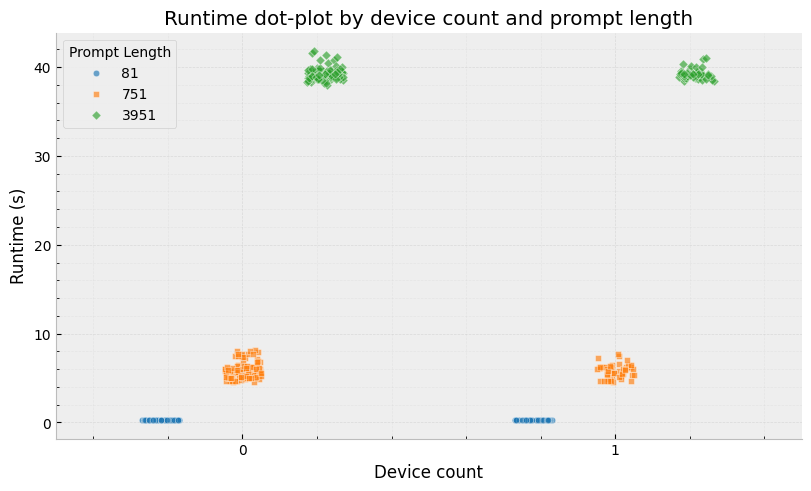

In [62]:

# Dot-plot of individual runs: time vs. device_count, colored by prompt length with slight jitter
lengths = list(stats["prompt_length"].unique())
offsets = np.linspace(-0.22, 0.22, num=len(lengths))
jitter = 0.05

fig2, ax2 = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

for idx, length in enumerate(lengths):
    d = data[data["prompt_length"] == length]
    rng = np.random.default_rng(100 + idx)
    x = d["device_count"].to_numpy(dtype=float) + offsets[idx] + rng.uniform(-jitter, jitter, size=len(d))
    ax2.scatter(
        x, d["time"],
        s=22, alpha=0.65,
        color=cmap(idx % 10),
        marker=markers[idx % len(markers)],
        edgecolor="white", linewidth=0.4,
        label=length,
    )

ax2.set_xticks(xticks)
ax2.set_xlim(min(xticks) - 0.5, max(xticks) + 0.5)
ax2.set_xlabel("Device count")
ax2.set_ylabel("Runtime (s)")
ax2.set_title("Runtime dot-plot by device count and prompt length")

ax2.grid(which="major", alpha=0.35)
ax2.minorticks_on()
ax2.grid(which="minor", alpha=0.15, linestyle="--")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

ax2.legend(title="Prompt Length", frameon=True, fancybox=True, framealpha=0.9)
plt.show()

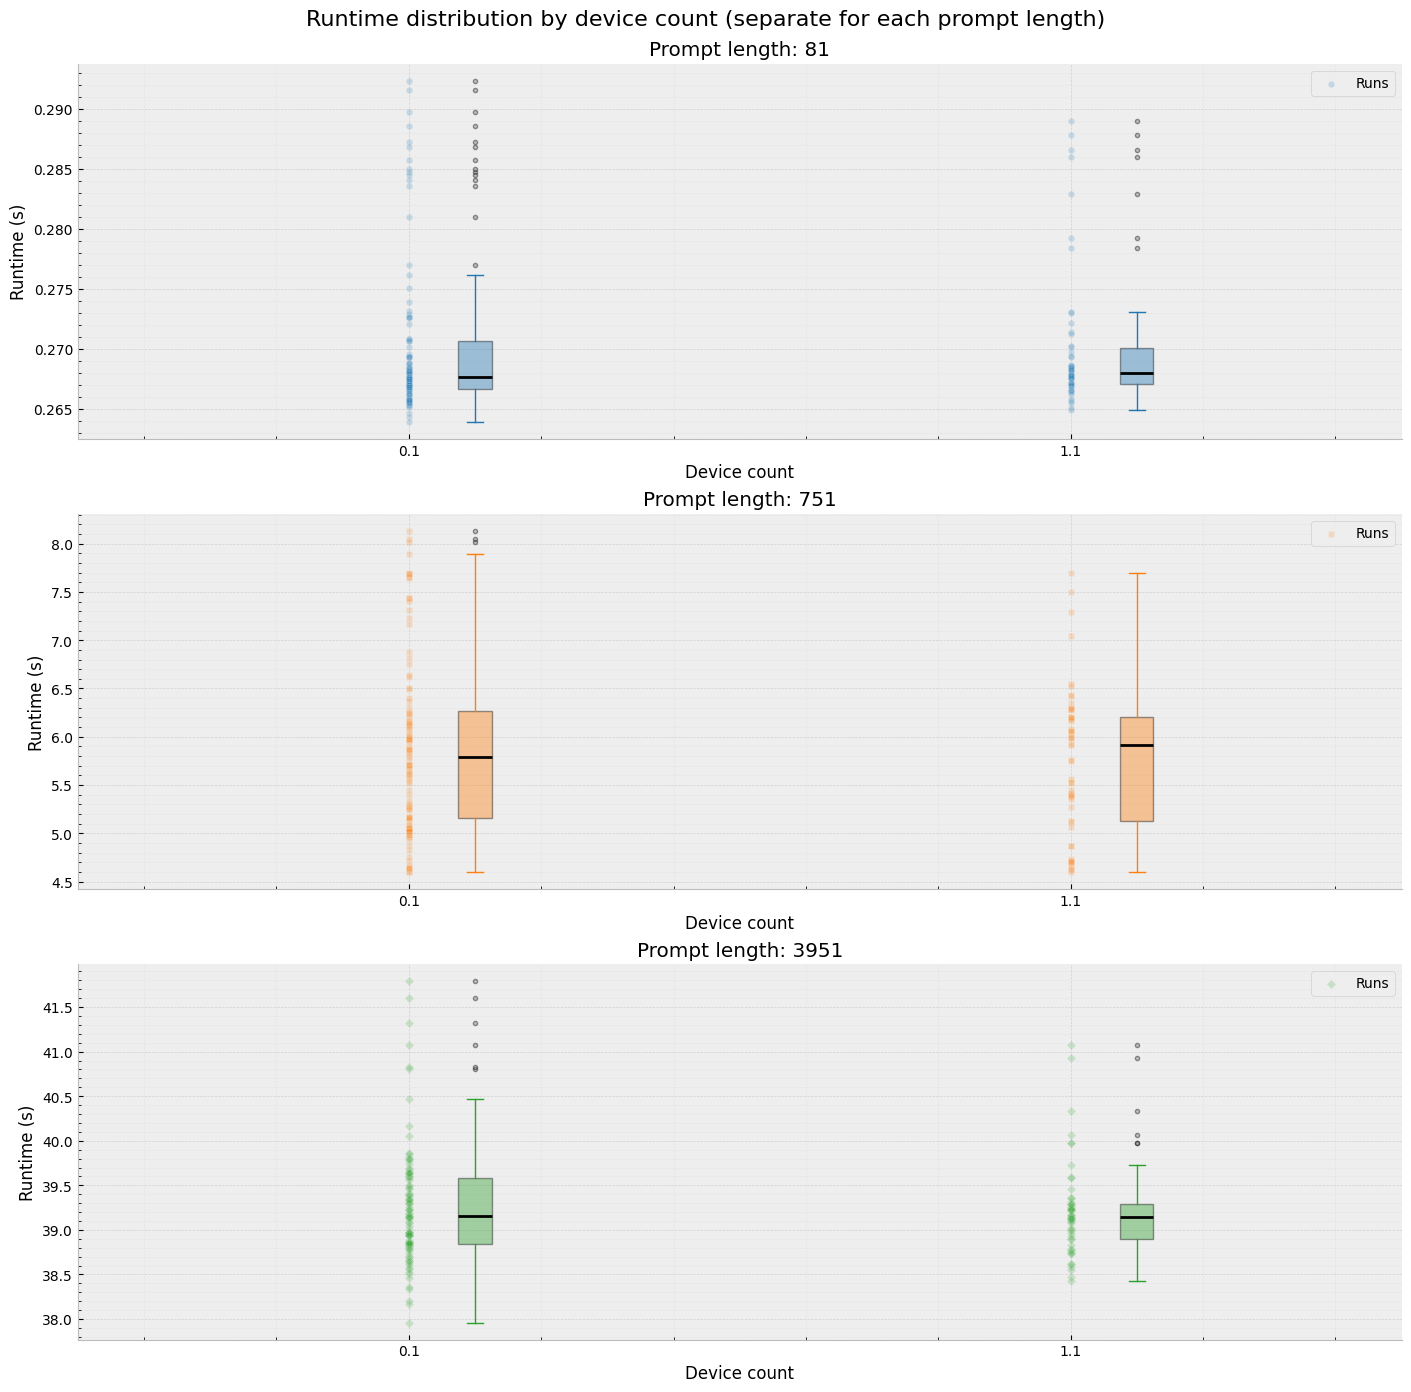

In [64]:
# Plot runtime distribution for each prompt length in separate subplots
plt.style.use("bmh")
lengths = list(stats["prompt_length"].unique())
colors = [cmap(i % 10) for i in range(len(lengths))]
markers = ["o", "s", "D", "^", "v", "P", "X", "*", "h", ">"]

nrows = int(len(lengths))
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(14, 4.5 * nrows), constrained_layout=True)
axes = axes.flatten() if len(lengths) > 1 else [axes]

for idx, length in enumerate(lengths):
    ax = axes[idx]
    d = data[data["prompt_length"] == length]
    x = d["device_count"].to_numpy(dtype=float)
    # Plot individual runs (dot plot, no jitter)
    ax.scatter(
        x,
        d["time"],
        s=22,
        alpha=0.2,
        color=colors[idx],
        marker=markers[idx % len(markers)],
        edgecolor="white",
        linewidth=0.4,
        label="Runs",
    )

    positions = sorted(d["device_count"].unique())
    xd = [d.loc[d["device_count"] == dc, "time"] for dc in positions]

    bp = ax.boxplot(
        xd,
        positions=[p + 0.1 for p in positions],  # small offset like you had
        widths=0.05,
        patch_artist=True,
        boxprops=dict(facecolor=colors[idx], alpha=0.4),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color=colors[idx]),
        capprops=dict(color=colors[idx]),
        flierprops=dict(marker="o", markerfacecolor="gray", alpha=0.4, markersize=3),
    )

    ax.set_xticks(xticks)
    ax.set_xlim(min(xticks) - 0.5, max(xticks) + 0.5)
    ax.set_xlabel("Device count")
    ax.set_ylabel("Runtime (s)")
    ax.set_title(f"Prompt length: {length}")
    ax.grid(which="major", alpha=0.5)
    ax.minorticks_on()
    ax.grid(which="minor", alpha=0.15, linestyle="--")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(frameon=True, fancybox=True, framealpha=0.9, loc="best")

# Hide unused subplots if any
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Runtime distribution by device count (separate for each prompt length)", fontsize=16, y=1.02)
plt.show()
